# ML: SUPERVISED LEARNING_CUSTOMER CHURN PREDICTOR
## PHASE 0 - ENVIRONMENT SETUP: Installing and Importing Libraries

In [1]:
# Install and import All required Libraries

# --- Safe Installation Method for Windows ---
import sys
import subprocess

packages = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'xgboost',
    'imbalanced-learn',
    'openpyxl'
]

for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '--quiet'])

print("All Packages installed")

# --- Core Data Libraries
import pandas as pd
import numpy as np

# --- Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# --- Display Setting
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

print("All Libraries Loaded Successfully")


All Packages installed
All Libraries Loaded Successfully


## PHASE 1 - Loading the Dataset

In [2]:
# Loading Dataset
df = pd.read_excel('C:/Users/USER/Desktop/Datafrik.co/AI-ML Introductory Course/Day 3/Customer Churn Dataset.xlsx')

print(f"Dataset Loaded! Shape: {df.shape}")

Dataset Loaded! Shape: (7043, 21)


In [3]:
# Preview our data
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


# Inspect the Dataset Structure


In [4]:
# Dataset Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## PHASE 2 - CLEANED AND ENCODED DATA

In [5]:
# Fix 1: Convert SeniorCitizen from 0/1 to Yes/No
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1:'Yes'})

df['SeniorCitizen'].unique()

array(['No', 'Yes'], dtype=object)

In [6]:
# Fix 2: Checking for Missing Values and Fix
df.isnull().sum()


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
# Investigating Missing values in TotalCharges
# Show rows where TotalCharge is missing

df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [8]:
# Handling Missing Values
# Replace all missing values with 0

df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Verify
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
# Checking unique values in every column

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    print(f"{col:20s} > {df[col].unique().tolist()}")
    print()

customerID           > ['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU', '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU', '9763-GRSKD', '7469-LKBCI', '8091-TTVAX', '0280-XJGEX', '5129-JLPIS', '3655-SNQYZ', '8191-XWSZG', '9959-WOFKT', '4190-MFLUW', '4183-MYFRB', '8779-QRDMV', '1680-VDCWW', '1066-JKSGK', '3638-WEABW', '6322-HRPFA', '6865-JZNKO', '6467-CHFZW', '8665-UTDHZ', '5248-YGIJN', '8773-HHUOZ', '3841-NFECX', '4929-XIHVW', '6827-IEAUQ', '7310-EGVHZ', '3413-BMNZE', '6234-RAAPL', '6047-YHPVI', '6572-ADKRS', '5380-WJKOV', '8168-UQWWF', '8865-TNMNX', '9489-DEDVP', '9867-JCZSP', '4671-VJLCL', '4080-IIARD', '3714-NTNFO', '5948-UJZLF', '7760-OYPDY', '7639-LIAYI', '2954-PIBKO', '8012-SOUDQ', '9420-LOJKX', '6575-SUVOI', '7495-OOKFY', '4667-QONEA', '1658-BYGOY', '8769-KKTPH', '5067-XJQFU', '3957-SQXML', '5954-BDFSG', '0434-CSFON', '1215-FIGMP', '0526-SXDJP', '0557-ASKVU', '5698-BQJOH', '5122-CYFXA', '8627-ZYGSZ', '3410-YOQBQ', '3170-NMYVV', '7410-OIED

## Drop Unnecessary Columns and Encode Categories

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
# Drop Customer ID & Encode All Categorical Columns

# Step 1: Drop Customer ID
df = df.drop(columns=['customerID'])

# Step 2: Columns where "No internet service" = "No"

no_internet_columns = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]

for col in no_internet_columns:
    df[col] = df[col].replace({'No internet service': 'No',
                               'No phone service': 'No'})


# Step 3: Binary columns > Yes=1, No=0
binary_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'PaperlessBilling', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]

binary_map = {'Yes':1, 'No':0, 'Male':1, 'Female':0}
for col in binary_cols:
    df[col] = df[col].map(binary_map)

# Step 4: One-hot encoding for multi-category columns
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=False)

# Step 6: Encode target variable
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# Verify
print(f"Encoding complete! New Shape: {df.shape}")
print(f"\nChurn Value counts:\n{df['Churn'].value_counts()}")
print(f"\nSample of new columns: {df.columns.tolist()}")

Encoding complete! New Shape: (7043, 27)

Churn Value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Sample of new columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [12]:
df.head(10)
df.isnull().sum()

gender                                     0
SeniorCitizen                              0
Partner                                    0
Dependents                                 0
tenure                                     0
PhoneService                               0
MultipleLines                              0
OnlineSecurity                             0
OnlineBackup                               0
DeviceProtection                           0
TechSupport                                0
StreamingTV                                0
StreamingMovies                            0
PaperlessBilling                           0
MonthlyCharges                             0
TotalCharges                               0
Churn                                      0
InternetService_DSL                        0
InternetService_Fiber optic                0
InternetService_No                         0
Contract_Month-to-month                    0
Contract_One year                          0
Contract_T

## Summary Statistics

In [13]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,True,False,False,False,True,False,True,False,False,False
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1,False,True,False,True,False,False,False,False,True,False


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,7043.00,0.50,0.50,0.00,0.00,1.00,1.00,1.00
SeniorCitizen,7043.00,0.16,0.37,0.00,0.00,0.00,0.00,1.00
Partner,7043.00,0.48,0.50,0.00,0.00,0.00,1.00,1.00
Dependents,7043.00,0.30,0.46,0.00,0.00,0.00,1.00,1.00
tenure,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
PhoneService,7043.00,0.90,0.30,0.00,1.00,1.00,1.00,1.00
MultipleLines,7043.00,0.42,0.49,0.00,0.00,0.00,1.00,1.00
OnlineSecurity,7043.00,0.29,0.45,0.00,0.00,0.00,1.00,1.00
OnlineBackup,7043.00,0.34,0.48,0.00,0.00,0.00,1.00,1.00
DeviceProtection,7043.00,0.34,0.48,0.00,0.00,0.00,1.00,1.00


## PHASE 3 - EXPLORATORY DATA ANALYSIS
### Univariate, Bivariate and Multivariate Analysis

Stayed: 5,174 (73.5%)
Churned: 1,869 (26.5%)


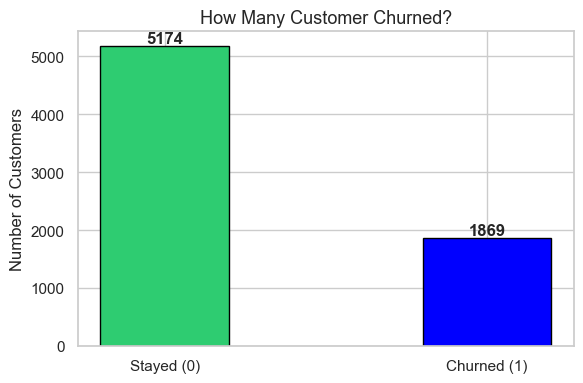

In [15]:
# Churn Distribution
# How many customers churned Vs stayed

churn_counts = df['Churn'].value_counts()

plt.figure(figsize = (6, 4))
plt.bar(['Stayed (0)', 'Churned (1)'], 
        churn_counts.values,
        color=['#2ecc71', 'blue'],
        edgecolor='black', width=0.4)

# Add the numbers on top of each bar
for i, v in enumerate(churn_counts.values):
    plt.text(i, v+50, str(v), ha='center', fontweight='bold')
    plt.title('How Many Customer Churned?', fontsize=13)
    plt.ylabel('Number of Customers')
    plt.tight_layout()
    plt.show

print (f"Stayed: {churn_counts[0]:,} ({churn_counts[0]/len(df)*100:.1f}%)")
print (f"Churned: {churn_counts[1]:,} ({churn_counts[1]/len(df)*100:.1f}%)")

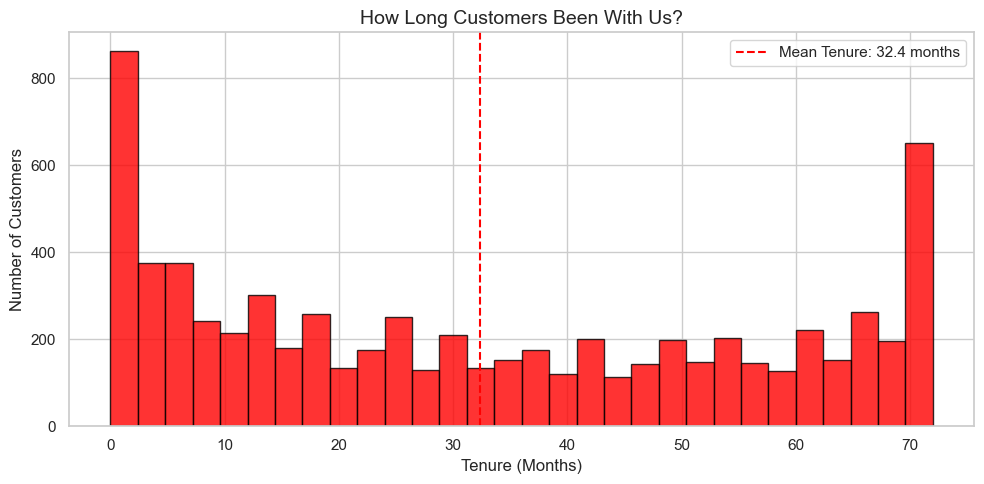

In [16]:
# Distribution of Tenure
plt.Figure(figsize=(8, 5))
plt.hist(df['tenure'], bins=30, color='red', edgecolor='black', alpha=0.8)
plt.axvline(df['tenure'].mean(), color='red', linestyle='--', label=f"Mean Tenure: {df['tenure'].mean():.1f} months")
plt.title ('How Long Customers Been With Us?', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

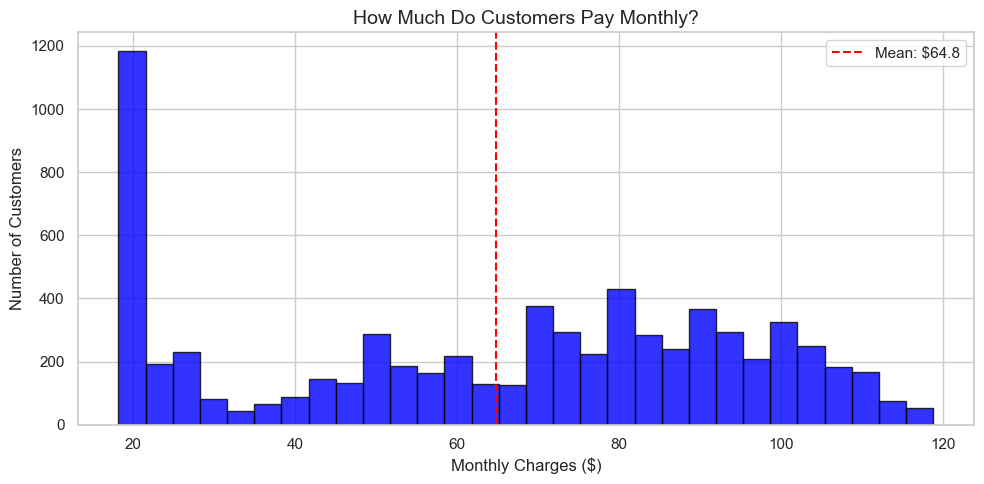

In [17]:
# Distribution of Monthly Charge

# Distribution of Tenure
plt.Figure(figsize=(8, 5))
plt.hist(df['MonthlyCharges'], bins=30, color='blue', edgecolor='black', alpha=0.8)
plt.axvline(df['MonthlyCharges'].mean(), color='red', linestyle='--', label=f"Mean: ${df['MonthlyCharges'].mean():.1f}")
plt.title ('How Much Do Customers Pay Monthly?', fontsize=14)
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

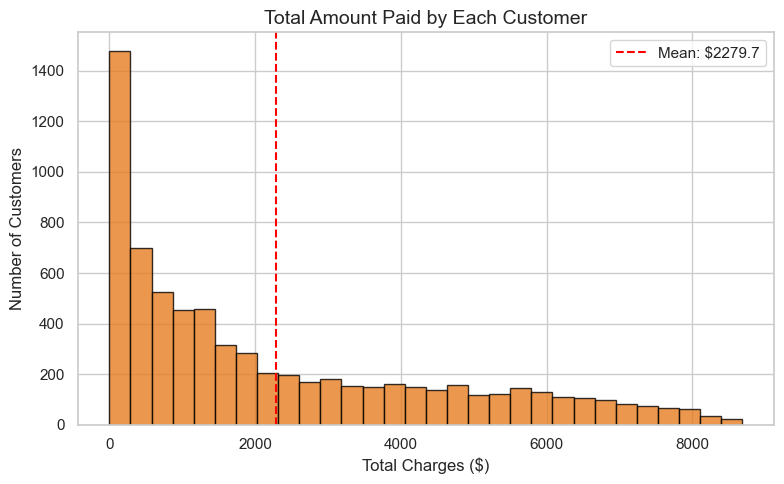

Lowest total  : $0.0
Average total : $2279.73
Highest total : $8684.8


In [18]:
# Distribution of Total Charges

plt.figure(figsize=(8, 5))
plt.hist(df['TotalCharges'], bins=30,
         color='#e67e22', edgecolor='black', alpha=0.8)

plt.axvline(df['TotalCharges'].mean(), color='red',
            linestyle='--',
            label=f"Mean: ${df['TotalCharges'].mean():.1f}")

plt.title('Total Amount Paid by Each Customer', fontsize=14)
plt.xlabel('Total Charges ($)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Lowest total  : ${df['TotalCharges'].min()}")
print(f"Average total : ${df['TotalCharges'].mean():.2f}")
print(f"Highest total : ${df['TotalCharges'].max()}")

## BIVARIATE ANALYSIS

<Figure size 700x500 with 0 Axes>

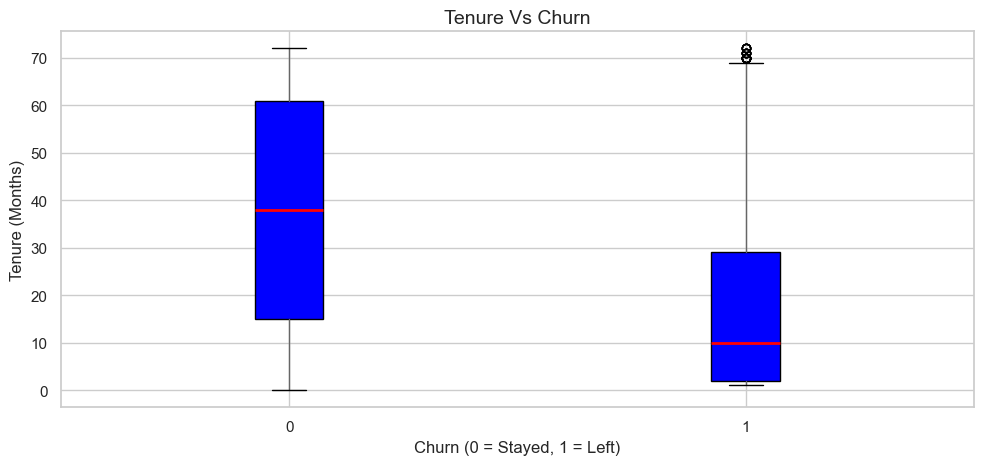

Average tenure by Churn status:
Churn
0   37.60
1   18.00
Name: tenure, dtype: float64


In [22]:
# Do churners leave early?
# "How long do churners stay before they leave"

plt.figure(figsize=(7,5))
df.boxplot(column= 'tenure', by= 'Churn', patch_artist = True, 
           boxprops=dict(facecolor='blue', color='black'), 
           medianprops=dict(color='red', linewidth=2))

plt.title('Tenure Vs Churn', fontsize=14)
plt.suptitle('')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Tenure (Months)')
plt.tight_layout()
plt.show()


# print average tenure for each group
print("Average tenure by Churn status:")
print(df.groupby('Churn')['tenure'].mean().round(1))


<Figure size 700x500 with 0 Axes>

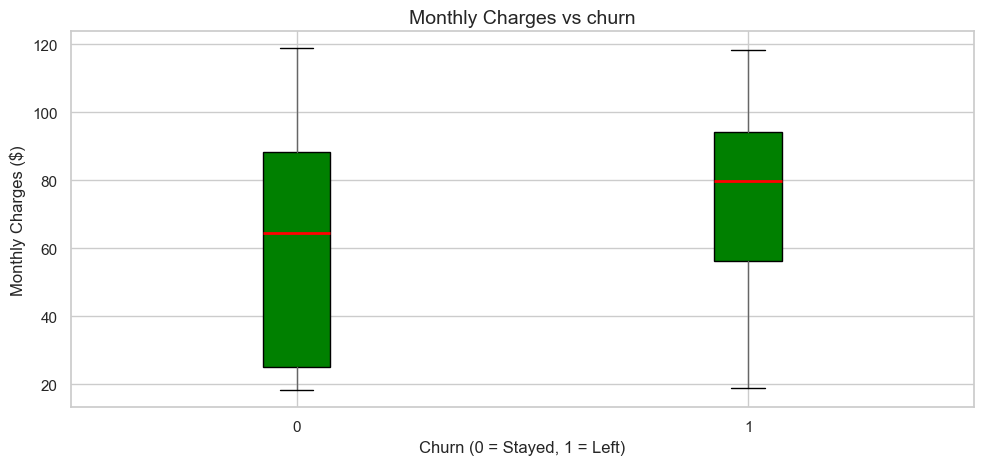

Average Monthly Charge by Churn status:
Churn
0   61.27
1   74.44
Name: MonthlyCharges, dtype: float64


In [24]:
# Monthly Charges Vs Churn
# "Do Customers who pay more churn more"

plt.figure(figsize=(7,5))
df.boxplot(column='MonthlyCharges', by='Churn', 
           patch_artist = True, 
           boxprops=dict(facecolor='green', color='black'), 
           medianprops=dict(color='red', linewidth=2))

plt.title('Monthly Charges vs churn', fontsize=14)
plt.suptitle('')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

# print average monthly charge for each group
print("Average Monthly Charge by Churn status:")
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

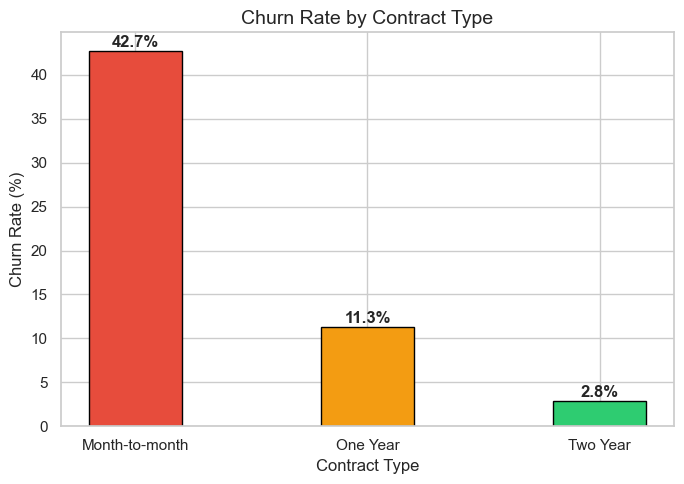

Churn Rate by Contract Type:
Contract_Type
Month-to-month   42.70
One Year         11.30
Two Year          2.80
Name: Churn, dtype: float64


In [25]:
# Contract Type vs Churn

# Calculate churn rate per contract type
contract_churn = df.groupby([
    'Contract_Month-to-month',
    'Contract_One year',
    'Contract_Two year'
])['Churn'].mean() * 100

# Simpler approach — rebuild contract column for plotting
df['Contract_Type'] = 'Month-to-month'
df.loc[df['Contract_One year'] == 1, 'Contract_Type'] = 'One Year'
df.loc[df['Contract_Two year'] == 1, 'Contract_Type'] = 'Two Year'

churn_by_contract = df.groupby('Contract_Type')['Churn'].mean() * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(churn_by_contract.index,
               churn_by_contract.values,
               color=['#e74c3c', '#f39c12', '#2ecc71'],
               edgecolor='black', width=0.4)

# Add percentage labels on bars
for bar, val in zip(bars, churn_by_contract.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Contract Type', fontsize=14)
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

print("Churn Rate by Contract Type:")
print(churn_by_contract.round(1))

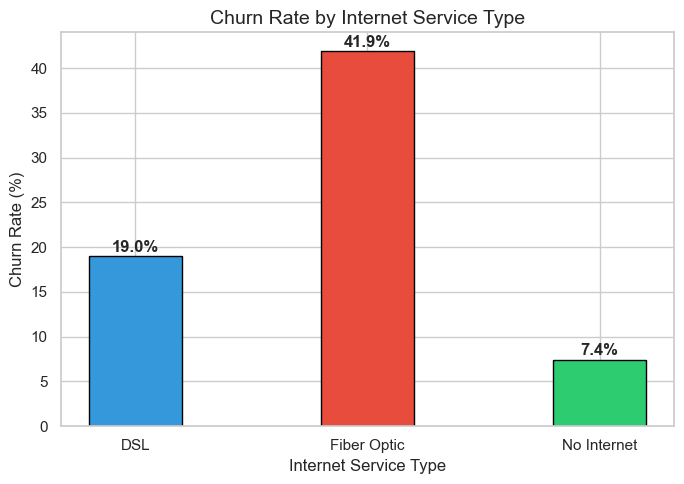

Churn Rate by Internet Service:
Internet_Type
DSL           19.00
Fiber Optic   41.90
No Internet    7.40
Name: Churn, dtype: float64


In [26]:
# Internet Service vs Churn

# Rebuild internet service column for plotting
df['Internet_Type'] = 'No Internet'
df.loc[df['InternetService_DSL'] == 1, 'Internet_Type'] = 'DSL'
df.loc[df['InternetService_Fiber optic'] == 1, 'Internet_Type'] = 'Fiber Optic'

churn_by_internet = df.groupby('Internet_Type')['Churn'].mean() * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(churn_by_internet.index,
               churn_by_internet.values,
               color=['#3498db', '#e74c3c', '#2ecc71'],
               edgecolor='black', width=0.4)

for bar, val in zip(bars, churn_by_internet.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Internet Service Type', fontsize=14)
plt.xlabel('Internet Service Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

print("Churn Rate by Internet Service:")
print(churn_by_internet.round(1))

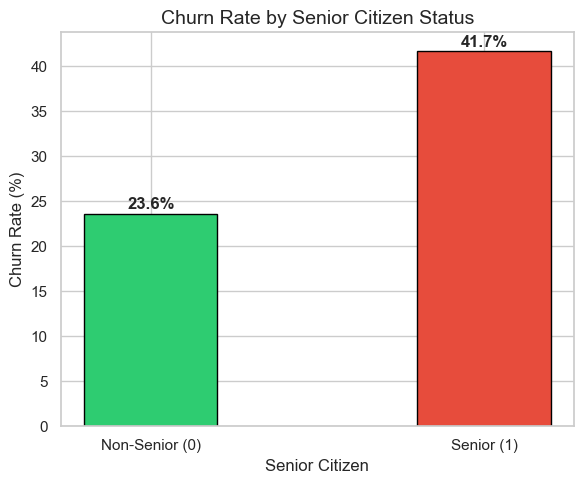

Churn Rate by Senior Citizen Status:
SeniorCitizen
0   23.60
1   41.70
Name: Churn, dtype: float64

Customer Count by Senior Citizen Status:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


In [27]:
# Senior Citizen vs Churn

churn_by_senior = df.groupby('SeniorCitizen')['Churn'].mean() * 100

plt.figure(figsize=(6, 5))
bars = plt.bar(['Non-Senior (0)', 'Senior (1)'],
               churn_by_senior.values,
               color=['#2ecc71', '#e74c3c'],
               edgecolor='black', width=0.4)

for bar, val in zip(bars, churn_by_senior.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Senior Citizen Status', fontsize=14)
plt.xlabel('Senior Citizen')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

print("Churn Rate by Senior Citizen Status:")
print(churn_by_senior.round(1))

print("\nCustomer Count by Senior Citizen Status:")
print(df['SeniorCitizen'].value_counts())

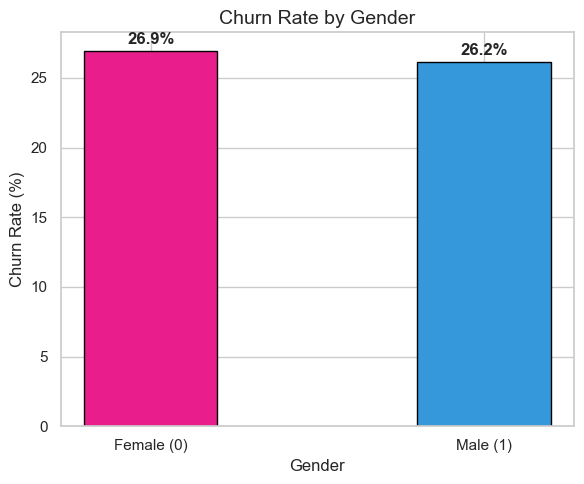

Churn Rate by Gender:
gender
0   26.90
1   26.20
Name: Churn, dtype: float64


In [28]:
# Gender vs Churn

churn_by_gender = df.groupby('gender')['Churn'].mean() * 100

plt.figure(figsize=(6, 5))
bars = plt.bar(['Female (0)', 'Male (1)'],
               churn_by_gender.values,
               color=['#e91e8c', '#3498db'],
               edgecolor='black', width=0.4)

for bar, val in zip(bars, churn_by_gender.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

print("Churn Rate by Gender:")
print(churn_by_gender.round(1))

## MULTIVARIATE ANALYSIS

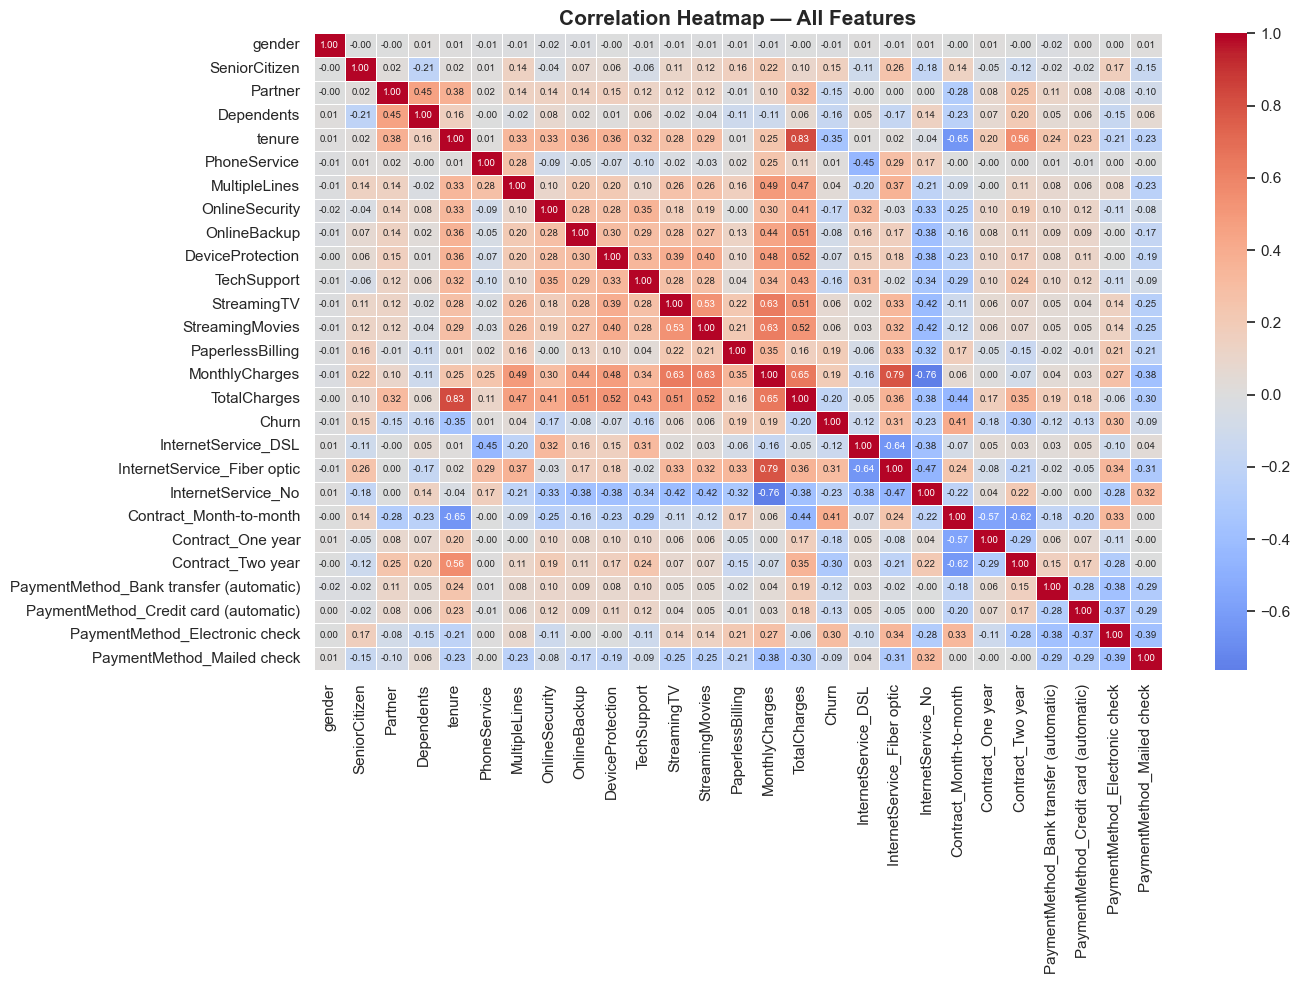

Correlation with Churn (ranked):
Churn                                      1.00
Contract_Month-to-month                    0.41
InternetService_Fiber optic                0.31
PaymentMethod_Electronic check             0.30
MonthlyCharges                             0.19
PaperlessBilling                           0.19
SeniorCitizen                              0.15
StreamingTV                                0.06
StreamingMovies                            0.06
MultipleLines                              0.04
PhoneService                               0.01
gender                                    -0.01
DeviceProtection                          -0.07
OnlineBackup                              -0.08
PaymentMethod_Mailed check                -0.09
PaymentMethod_Bank transfer (automatic)   -0.12
InternetService_DSL                       -0.12
PaymentMethod_Credit card (automatic)     -0.13
Partner                                   -0.15
Dependents                                -0.16
TechSup

In [29]:
# Correlation Heatmap

# Drop the temporary columns we created for plotting
df_corr = df.drop(columns=['Contract_Type',
                            'Internet_Type'], errors='ignore')

plt.figure(figsize=(14, 10))
corr_matrix = df_corr.corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 7})

plt.title('Correlation Heatmap — All Features',
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Print just the Churn correlations ranked
print("Correlation with Churn (ranked):")
print(corr_matrix['Churn'].sort_values(ascending=False).round(2))

## FEATURE ENGINEERING AND PREPARING FOR MODELLING

In [30]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract_Type,Internet_Type
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,True,False,False,True,False,False,False,False,True,False,Month-to-month,DSL
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,True,False,False,False,True,False,False,False,False,True,One Year,DSL
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,Month-to-month,DSL
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,True,False,False,False,True,False,True,False,False,False,One Year,DSL
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1,False,True,False,True,False,False,False,False,True,False,Month-to-month,Fiber Optic


In [31]:
# Vertical Split
# Separate Features (X) and Target (y)

# Drop temporary plotting columns and target to get X
# Feature Matrix
X = df.drop(columns=['Churn',
                      'Contract_Type',
                      'Internet_Type'], errors='ignore')

# Target variable
y = df['Churn']

print(f"✅ Features shape (X): {X.shape}")
print(f"✅ Target shape   (y): {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
for col in X.columns:
    print(f"   → {col}")
print(f"\nTarget distribution:")
print(y.value_counts())

✅ Features shape (X): (7043, 26)
✅ Target shape   (y): (7043,)

Feature columns (26):
   → gender
   → SeniorCitizen
   → Partner
   → Dependents
   → tenure
   → PhoneService
   → MultipleLines
   → OnlineSecurity
   → OnlineBackup
   → DeviceProtection
   → TechSupport
   → StreamingTV
   → StreamingMovies
   → PaperlessBilling
   → MonthlyCharges
   → TotalCharges
   → InternetService_DSL
   → InternetService_Fiber optic
   → InternetService_No
   → Contract_Month-to-month
   → Contract_One year
   → Contract_Two year
   → PaymentMethod_Bank transfer (automatic)
   → PaymentMethod_Credit card (automatic)
   → PaymentMethod_Electronic check
   → PaymentMethod_Mailed check

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [32]:
# Horizontal Split
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size =0.2, random_state=42, stratify=y)

print(f"Split complete!")
print(f"\nTraining set : {X_train.shape[0]} customers (80%)")
print(f"Test set     : {X_test.shape[0]} customers (20%)")
print(f"\nChurn rate in training set: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test set    : {y_test.mean()*100:.1f}%")


Split complete!

Training set : 5634 customers (80%)
Test set     : 1409 customers (20%)

Churn rate in training set: 26.5%
Churn rate in test set    : 26.5%
